# EDA: Titanic

## Цель: понять данные, оценить пропуски/распределения/связи с таргетом, и показать, что именно уходит в модель после `src.features.build_titanic_features` + `src.features.TabularPreprocessor`. 
Всё, что касается обучения моделей - в `Modeling_Titanic.ipynb`

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

# --- bootstrap: кладём корень проекта в sys.path ---
# (в ноутбуке из папки notebooks/ это нужно, чтобы импортировался src/)
_current = Path.cwd().resolve()
for _p in [_current, *_current.parents]:
    if (_p / "src").exists():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        PROJECT_ROOT = _p
        break
else:
    raise RuntimeError("Не нашёл корень проекта (папку с src/)")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import get_config
from src.features import build_titanic_features, TabularPreprocessor
from src.utils import set_seed

set_seed(42)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)


PROJECT_ROOT = C:\Users\xmxlx\Desktop\Final Project


In [3]:
# --- конфиг проекта ---
config = get_config("titanic")
TARGET = config["target"]
ID_COL = config["id_column"]
print("target:", TARGET, "| id:", ID_COL)
print("train_path:", config["data"]["train_path"])
print("test_path: ", config["data"]["test_path"])


# --- загрузка данных ---
train_df = pd.read_csv(config["data"]["train_path"])
test_df = pd.read_csv(config["data"]["test_path"])
print(f"train: {train_df.shape}, test: {test_df.shape}")

df = train_df.copy()  # EDA смотрим по train (в test таргета нет)

target: Survived | id: PassengerId
train_path: C:\Users\xmxlx\Desktop\Final Project\data\titanic\train_titanic.csv
test_path:  C:\Users\xmxlx\Desktop\Final Project\data\titanic\test_titanic.csv
train: (891, 12), test: (418, 11)


## 1. Общая статистика

In [4]:
df.info()

display(df.head(3))

display(df.describe())


cat_cols = ["Sex", "Pclass", "Embarked", "SibSp", "Parch"]
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

SibSp:
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Parch:
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


## 2. Пропуски

## Стратегии заполнения/удаления заданы в `configs/titanic.yaml`:
- `drop_columns`: PassengerId, Name, Ticket, Cabin
- `fillna`: Age => median, Far => median, Embarked => mode
Здесь мы только смотрим масштаб пропусков; сам fillna делает `TabularPreprocessor`.

,missing,pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


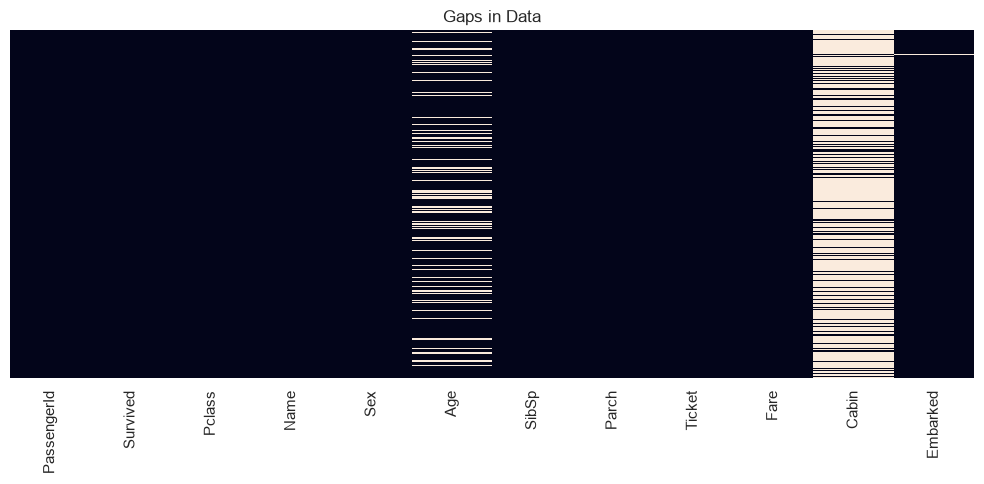

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({"missing": missing, "pct": missing_pct})[missing > 0])


plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Gaps in Data")
plt.tight_layout()
plt.show()

## **Вывод:** пропуски в `Age` (~20%), `Cabin` (~77%), `Embarked` (~0.2%).
`Cabin` дропаем (в конфиге), `Age` => медиана, `Embarked` => мода - тоже из конфига.
Проверим, что эти колонки действительно в `drop_columns` / `fillna`:

In [6]:
print("drop_columns:", config["features"].get("drop_columns"))
print("fillna:      ", config["features"].get("fillna"))

drop_columns: ['PassengerId', 'Name', 'Ticket', 'Cabin']
fillna:       {'Age': 'median', 'Fare': 'median', 'Embarked': 'mode'}


## 3. Распределения

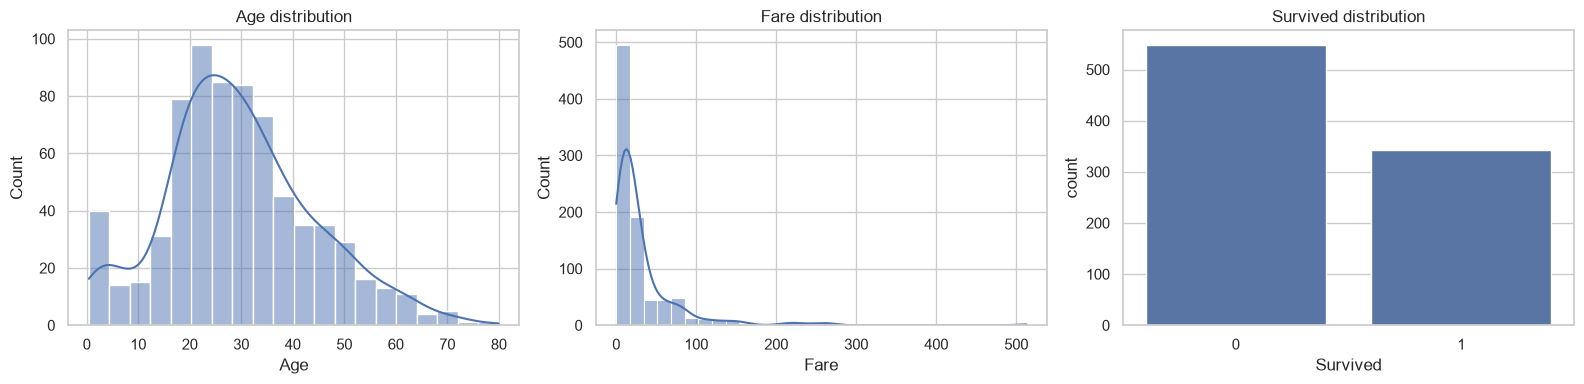

Survived: 38.4% | Dead: 61.6%


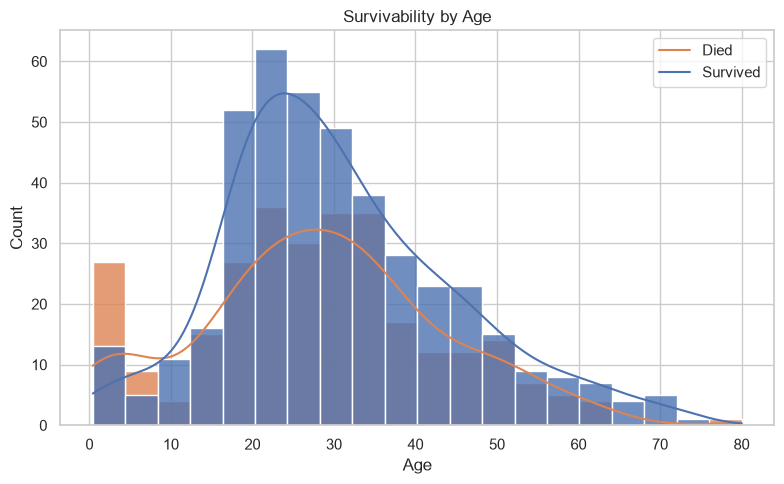

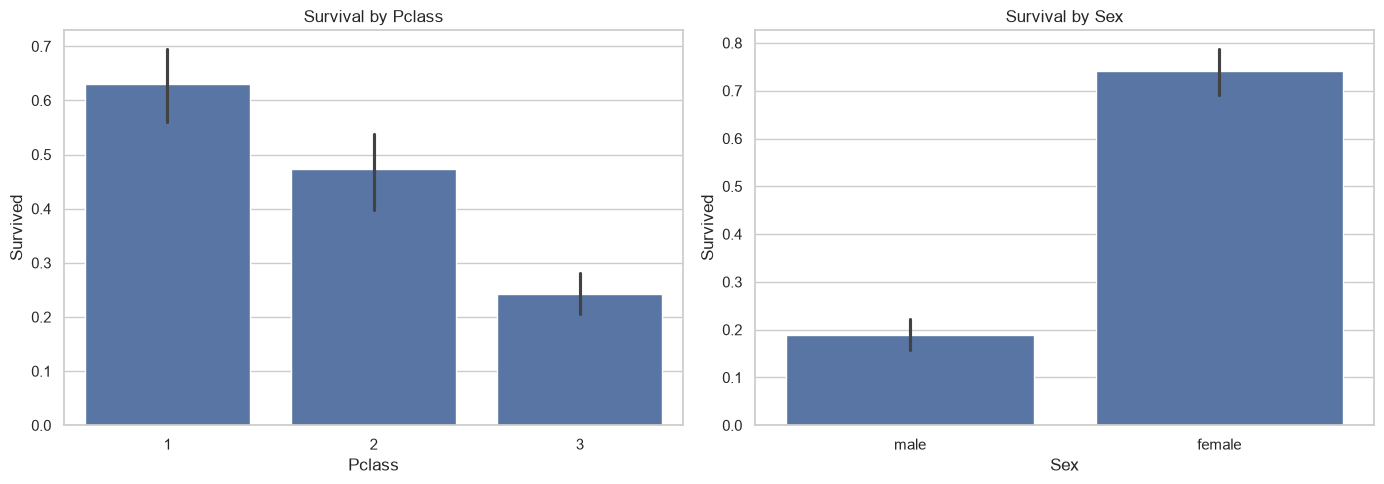

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"].dropna(), bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age distribution")

sns.histplot(df["Fare"].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Fare distribution")

sns.countplot(data=df, x=TARGET, ax=axes[2])
axes[2].set_title(f"{TARGET} distribution")
plt.tight_layout()
plt.show()

print(f"Survived: {df[TARGET].mean()*100:.1f}% | Dead: {(1-df[TARGET].mean())*100:.1f}%")


plt.figure(figsize=(8, 5))
sns.histplot(data=df.dropna(subset=["Age"]), x="Age", hue=TARGET,
             bins=20, kde=True, alpha=0.7)
plt.title("Survivability by Age")
plt.legend(["Died", "Survived"])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x="Pclass", y=TARGET, ax=axes[0])
axes[0].set_title("Survival by Pclass")

sns.barplot(data=df, x="Sex", y=TARGET, ax=axes[1])
axes[1].set_title("Survival by Sex")
plt.tight_layout()
plt.show()

## 4. Корреляции числовых признаков

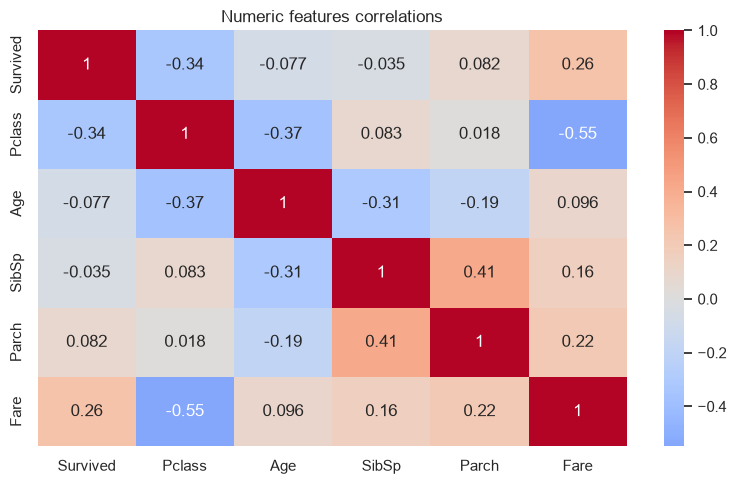

In [8]:
numeric_cols = [TARGET, "Pclass", "Age", "SibSp", "Parch", "Fare"]
plt.figure(figsize=(8, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Numeric features correlations")
plt.tight_layout()
plt.show()

 Fare | Survived: +0.26 (Присутсвует небольшая связь. Чем больше заплатил за билет, тем больше шансов выжить)
 
 Age | Survived: -0.077 (Очень слабая связь. Дети выживали чаще, но корреляция слабая)
 
 SibSP | Survived: -0.035 (Практически нет связи)
 
 Parch | Survived: +0.082 (Очень слабая положительная связь между выживаемостью и наличием родственников пассажира на борту)
 
 Pclass | Survived: -0.34 (Чем дешевле класс (1,2,3), тем меньше шансов выжить

 То есть, самые важные признаки для выживания - Pclass и Fare. 

## 5. Feature engineering + препроцессинг: что уйдёт в модель
FE делается функцией `src.features.build_titanic_features` (одна и та же
и в EDA, и в `main.py`). Препроцессинг - `TabularPreprocessor` (fit на train).

In [9]:
df_fe = build_titanic_features(train_df)
print("До FE:  ", train_df.shape)
print("После FE:", df_fe.shape)
new_cols = sorted(set(df_fe.columns) - set(train_df.columns))
print("Новые колонки:", new_cols)

display(df_fe[["Name", "Title", "FamilySize", "IsAlone", "AgeGroup",
               "FarePerPerson", "HasCabin"]].head())

# прогоняем препроцессор на train - чтобы увидеть финальный набор признаков
prep = TabularPreprocessor(config)
try:
    X_all = prep.fit_transform(df_fe)
    y_all = prep.transform_target(df_fe[TARGET])
    print(f"После препроцессинга: X={X_all.shape}, y={y_all.shape}")
    print("Признаки:", list(X_all.columns))
except Exception as e:
    print("Препроцессор упал:", type(e).__name__, e)
    print("Скорее всего проблема в ordinal-конфиге AgeGroup "
          "(там {ordered, categories}, а _encode_ordinal ждёт mapping).")

До FE:   (891, 12)
После FE: (891, 18)
Новые колонки: ['AgeGroup', 'FamilySize', 'FarePerPerson', 'HasCabin', 'IsAlone', 'Title']


,Name,Title,FamilySize,IsAlone,AgeGroup,FarePerPerson,HasCabin
0,"Braund, Mr. Owen Harris",Mr,2,0,Adult,3.62500,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,Adult,35.64165,1
2,"Heikkinen, Miss. Laina",Miss,1,1,Adult,7.92500,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,Adult,26.55000,1
4,"Allen, Mr. William Henry",Mr,1,1,Adult,8.05000,0


После препроцессинга: X=(891, 17), y=(891,)
Признаки: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'HasCabin']


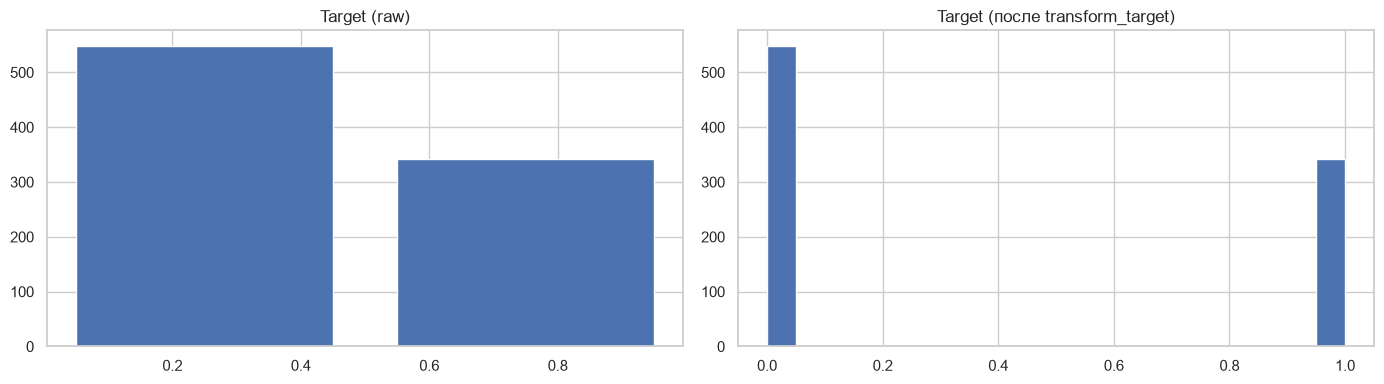

In [10]:
# распределение таргета после лог-трансформации (для titanic лог не нужен,
# но проверим, что transform_target не ломает)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_fe[TARGET].dropna(), bins=2, rwidth=0.8)
axes[0].set_title("Target (raw)")
axes[1].hist(y_all, bins=20)
axes[1].set_title("Target (после transform_target)")
plt.tight_layout()
plt.show()